# **Breast Cancer Classification**

## **Data Cleaning & Initial EDA**

### 1. Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer

plt.rcParams["figure.figsize"] = (10, 6)

This code imports the main libraries required for data analysis and visualization.
pandas is used for working with tabular data, numpy is used for numerical operations, matplotlib and seaborn are used for creating graphs, and load_breast_cancer is used to load the Breast Cancer Wisconsin dataset from sklearn. The figure size is also adjusted to make the plots easier to read.


### 2. Load Dataset

In [ ]:
data = load_breast_cancer()

df = pd.DataFrame(data.data, columns=data.feature_names)

df["target"] = data.target

df["diagnosis"] = df["target"].map({0: "Malignant", 1: "Benign"})

This block loads the dataset and converts it into a pandas DataFrame.
The feature values are stored in df, then the target variable is added as a new column. After that, a new column called diagnosis is created to make the target values easier to understand:

0 = Malignant

1 = Benign

### 3. Display First Rows

In [ ]:
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,Malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,Malignant


This command shows the first 5 rows of the dataset.
It is used to get a quick look at the data structure, feature names, and sample values.

### 4. Check Dataset Shape


In [ ]:
df.shape

(569, 32)

This command returns the number of rows and columns in the dataset.
It helps identify how many observations and variables are available for analysis.

### 5. List Column Names

In [ ]:
df.columns.tolist()

['mean radius',
 'mean texture',
 'mean perimeter',
 'mean area',
 'mean smoothness',
 'mean compactness',
 'mean concavity',
 'mean concave points',
 'mean symmetry',
 'mean fractal dimension',
 'radius error',
 'texture error',
 'perimeter error',
 'area error',
 'smoothness error',
 'compactness error',
 'concavity error',
 'concave points error',
 'symmetry error',
 'fractal dimension error',
 'worst radius',
 'worst texture',
 'worst perimeter',
 'worst area',
 'worst smoothness',
 'worst compactness',
 'worst concavity',
 'worst concave points',
 'worst symmetry',
 'worst fractal dimension',
 'target',
 'diagnosis']

This code lists all column names in the dataset.
It is useful for understanding the available features and checking whether all expected variables are present.

### 6. Check Data Types

In [ ]:
df.dtypes

,0
mean radius,float64
mean texture,float64
mean perimeter,float64
mean area,float64
mean smoothness,float64
mean compactness,float64
mean concavity,float64
mean concave points,float64
mean symmetry,float64
mean fractal dimension,float64


This command shows the data type of each column.
It helps confirm whether the features are numerical or categorical and whether any type conversion may be needed later.

### 7. General Dataset Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

This command provides a summary of the dataset, including:
*   the number of entries,
*   the number of non-null values,
*   the data type of each column.

It is especially useful for checking missing values quickly.


### 8. Missing Values Check

In [ ]:
print(df.isnull().sum())

total_missing = df.isnull().sum().sum()
print("Total missing values:", total_missing)

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
diagnosis                  0
dtype: int64
Total missing values: 0


This block checks for missing values in the dataset.
The first line shows the number of missing values in each column, and the second part calculates the total number of missing values across the whole dataset.

### 9. Duplicate Rows Check

In [ ]:
duplicates = df.duplicated().sum()

This code counts how many duplicate rows exist in the dataset.
Duplicate rows can affect model training because repeated records may bias the learning process.

### 10. Statistical Summary

In [ ]:
df.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,0.627417
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,0.483918
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,0.000000
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,0.000000
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,1.000000
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,1.000000
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,1.000000


This command generates summary statistics for all numerical columns, such as:


*   mean,
*   standard deviation,
*   minimum,
*   maximum,
*   quartiles.

This helps understand the overall distribution and scale of the variables.







### 11. Class Distribution Counts and Percentages

In [ ]:
print(df["diagnosis"].value_counts())

print(df["diagnosis"].value_counts(normalize=True) * 100)

diagnosis
Benign       357
Malignant    212
Name: count, dtype: int64
diagnosis
Benign       62.741652
Malignant    37.258348
Name: proportion, dtype: float64


This block calculates how many samples belong to each class and what percentage of the dataset each class represents.

It is important to check whether the dataset is balanced or imbalanced.

### 12. Class Distribution Plot

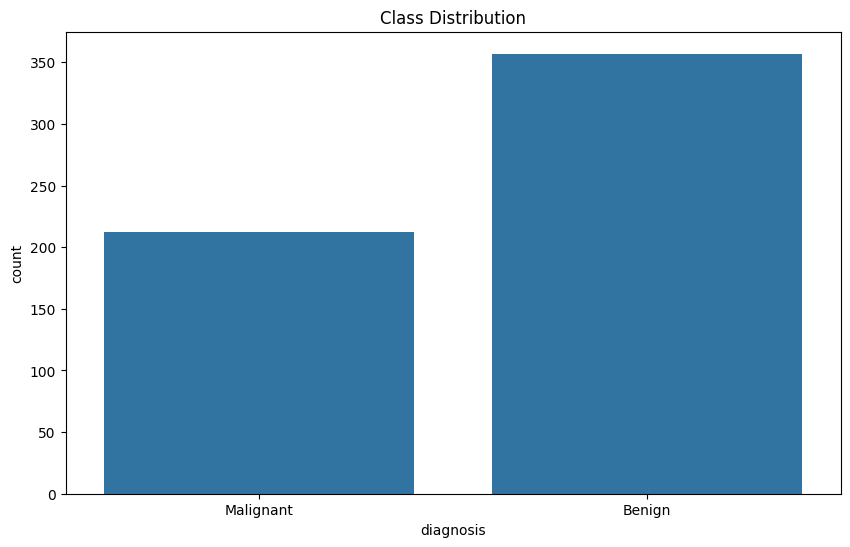

In [ ]:
sns.countplot(x="diagnosis", data=df)
plt.title("Class Distribution")
plt.show()

This code creates a bar chart showing the number of benign and malignant samples.
It provides a visual representation of the class balance.

### 13. Histograms of Selected Features

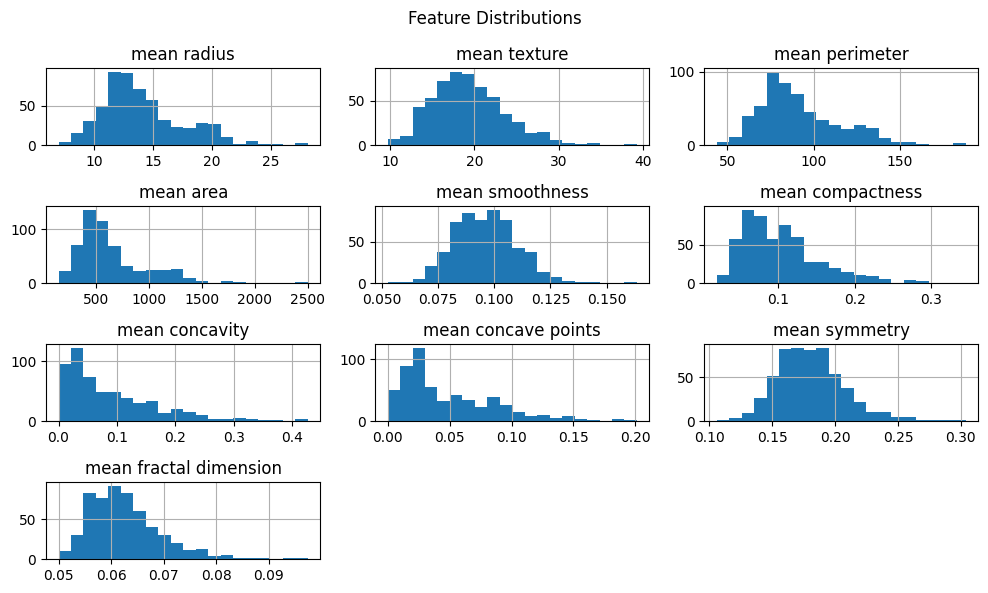

In [ ]:
selected_features = df.columns[:10]

df[selected_features].hist(bins=20)
plt.suptitle("Feature Distributions")
plt.tight_layout()
plt.show()

This block selects the first 10 features and draws histograms for them.
Histograms help show how values are distributed in each variable, whether the distribution is symmetric, skewed, or concentrated in certain ranges.

### 14. Boxplot for Outlier Analysis

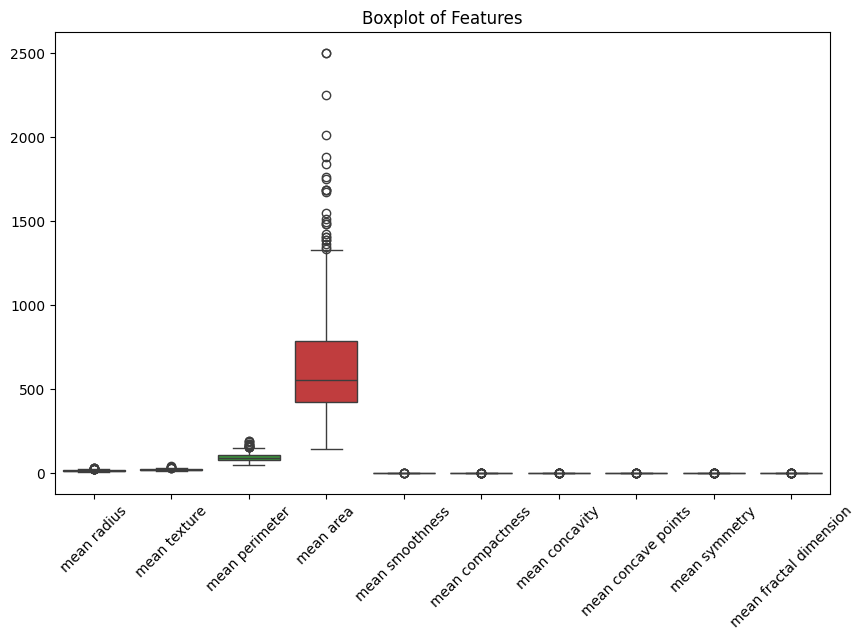

In [ ]:
sns.boxplot(data=df[selected_features])
plt.xticks(rotation=45)
plt.title("Boxplot of Features")
plt.show()

This code creates boxplots for the selected features.
Boxplots help identify:


*   the median,
*   spread of the data,
*   possible outliers.



### 15. Correlation Heatmap

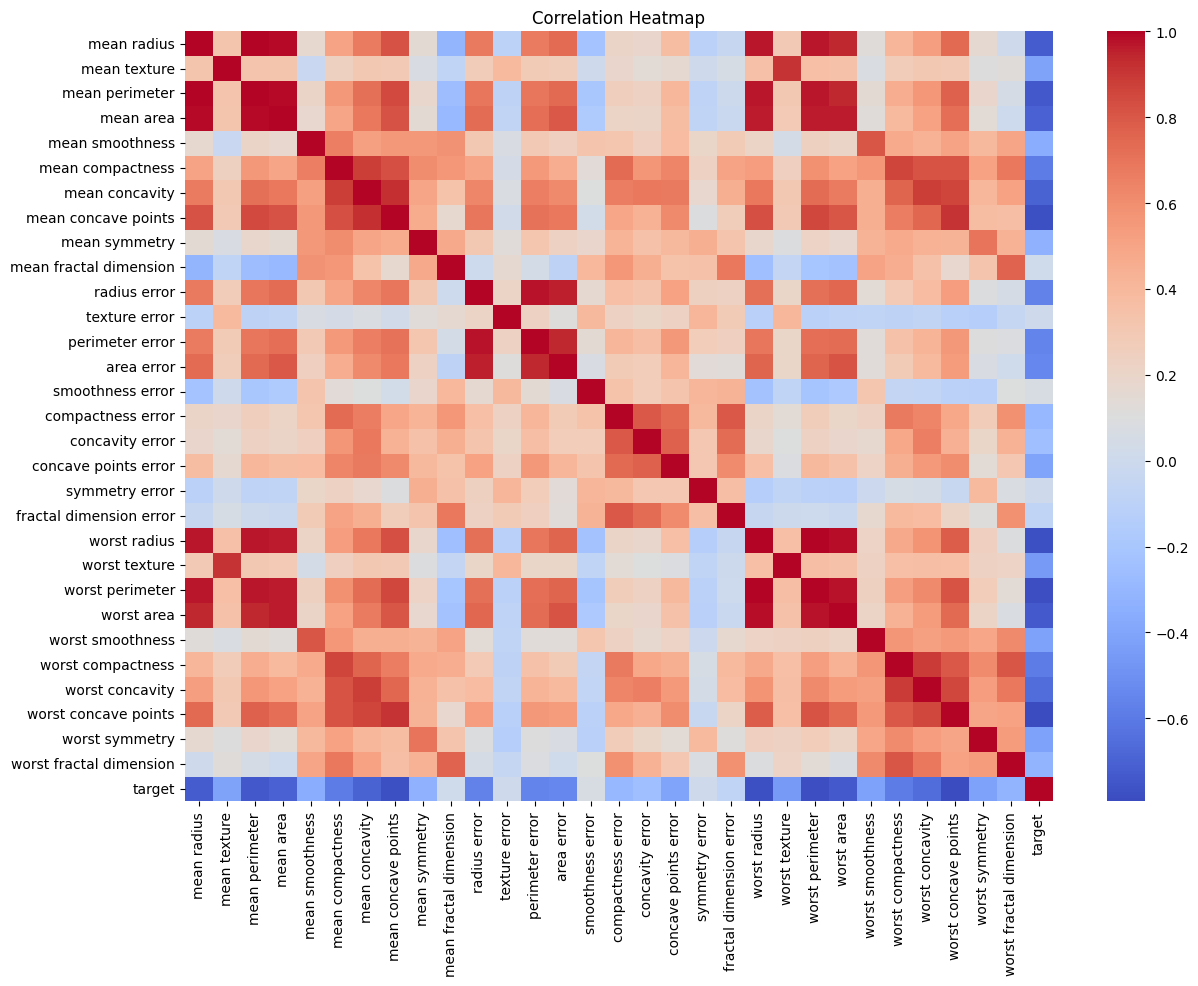

In [ ]:
numeric_df = df.drop(columns=["diagnosis"])

corr = numeric_df.corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

This block calculates the correlation matrix between numerical variables and visualizes it as a heatmap.
The diagnosis column is removed because it is categorical text. The heatmap helps show which variables are strongly positively or negatively related to each other.

### 16. Correlation with Target

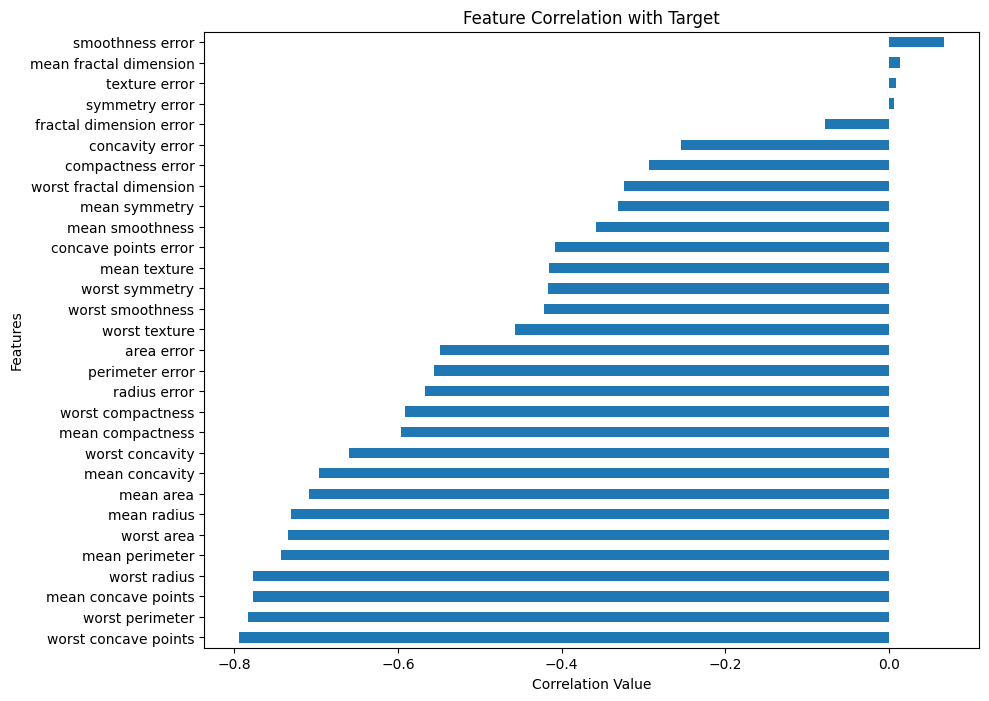

In [ ]:
target_corr = corr["target"].drop("target").sort_values()

plt.figure(figsize=(10, 8))
target_corr.plot(kind="barh")

plt.title("Feature Correlation with Target")
plt.xlabel("Correlation Value")
plt.ylabel("Features")
plt.show()

This code measures the relationship between each feature and the target variable.
The results are sorted and shown in a horizontal bar chart, making it easier to see which features are more strongly associated with the diagnosis outcome.

### 17. Group Means by Diagnosis

In [ ]:
group_means = df.groupby("diagnosis").mean(numeric_only=True)

group_means

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
diagnosis,,,,,,,,,,,,,,,,,,,,,
Benign,12.146524,17.914762,78.075406,462.790196,0.092478,0.080085,0.046058,0.025717,0.174186,0.062867,...,23.515070,87.005938,558.899440,0.124959,0.182673,0.166238,0.074444,0.270246,0.079442,1.0
Malignant,17.462830,21.604906,115.365377,978.376415,0.102898,0.145188,0.160775,0.087990,0.192909,0.062680,...,29.318208,141.370330,1422.286321,0.144845,0.374824,0.450606,0.182237,0.323468,0.091530,0.0


This block groups the data by diagnosis category and calculates the mean of each numerical feature for the benign and malignant classes.
It helps compare the average values of the two groups.

### 18. Boxplots for Important Features

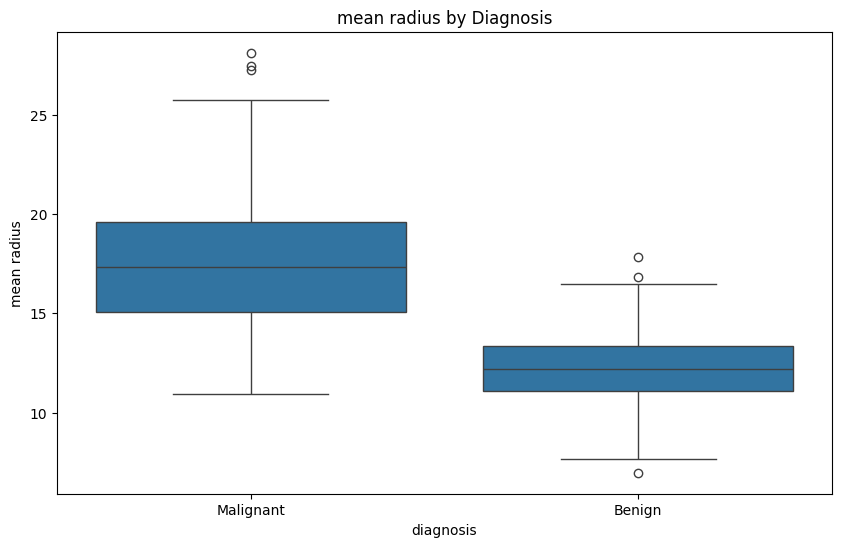

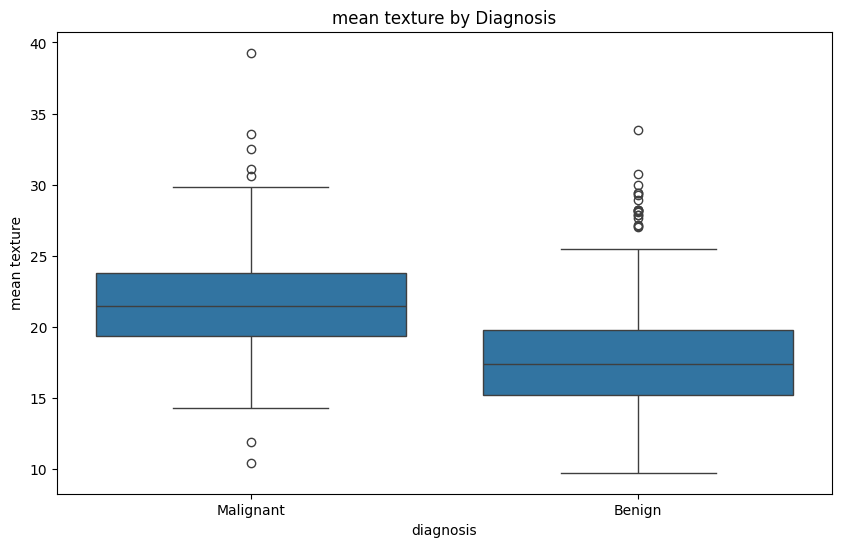

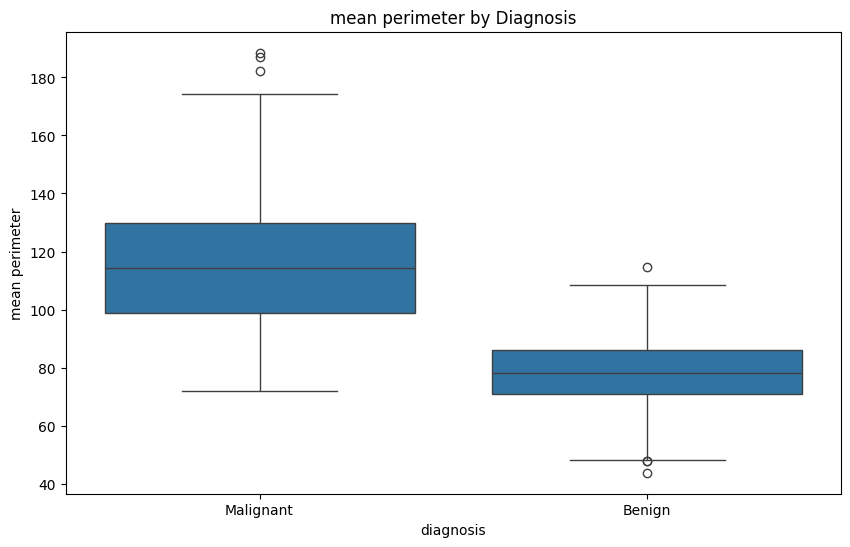

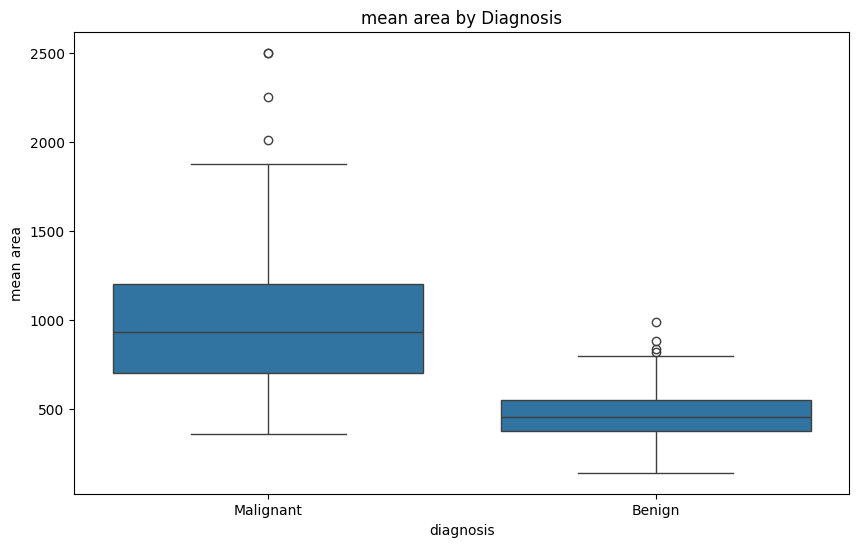

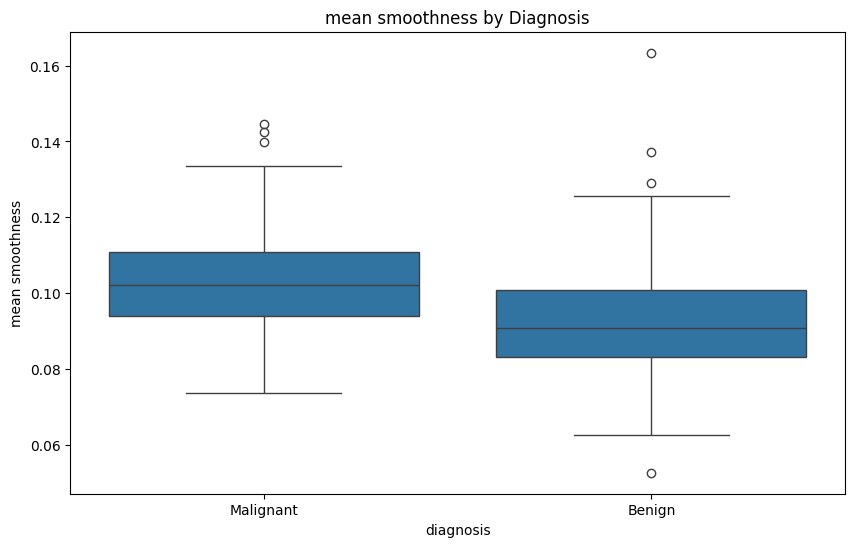

In [ ]:
important_features = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area",
    "mean smoothness"
]

for feature in important_features:
    plt.figure()
    sns.boxplot(x="diagnosis", y=feature, data=df)
    plt.title(f"{feature} by Diagnosis")
    plt.show()

This block focuses on a few important features and compares their distributions between benign and malignant tumors using boxplots.
These graphs make it easier to visually inspect class differences for clinically meaningful variables.

### 19. Outlier Detection Using IQR

In [ ]:
for col in df.columns[:-2]:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {outliers.shape[0]} outliers")

mean radius: 14 outliers
mean texture: 7 outliers
mean perimeter: 13 outliers
mean area: 25 outliers
mean smoothness: 6 outliers
mean compactness: 16 outliers
mean concavity: 18 outliers
mean concave points: 10 outliers
mean symmetry: 15 outliers
mean fractal dimension: 15 outliers
radius error: 38 outliers
texture error: 20 outliers
perimeter error: 38 outliers
area error: 65 outliers
smoothness error: 30 outliers
compactness error: 28 outliers
concavity error: 22 outliers
concave points error: 19 outliers
symmetry error: 27 outliers
fractal dimension error: 28 outliers
worst radius: 17 outliers
worst texture: 5 outliers
worst perimeter: 15 outliers
worst area: 35 outliers
worst smoothness: 7 outliers
worst compactness: 16 outliers
worst concavity: 12 outliers
worst concave points: 0 outliers
worst symmetry: 23 outliers
worst fractal dimension: 24 outliers


This code estimates the number of outliers in each feature using the IQR method.
The steps are:


*   calculate Q1 and Q3,
*   compute IQR,
*   determine lower and upper bounds,
*   count the observations outside those bounds.


### 20. Final Summary

In [ ]:
print("Total samples:", df.shape[0])
print("Total features:", df.shape[1] - 2)

print("Missing values:", total_missing)
print("Duplicate rows:", duplicates)

print(df["diagnosis"].value_counts())

print("""
Summary:
- No missing values
- No duplicate rows
- Slight class imbalance
- Outliers exist but kept
- Strong correlations between features
- Scaling will be needed
""")

Total samples: 569
Total features: 30
Missing values: 0
Duplicate rows: 0
diagnosis
Benign       357
Malignant    212
Name: count, dtype: int64

Summary:
- No missing values
- No duplicate rows
- Slight class imbalance
- Outliers exist but kept
- Strong correlations between features
- Scaling will be needed



This final block summarizes the most important findings from the data cleaning and EDA stage, including:

*   total number of samples,
*   total number of features,
*   duplicate rows,
*   class distribution,
*   general insights.


### General Conclusion
During this stage, the dataset was cleaned and an initial exploratory data analysis was conducted. The analysis confirmed that the dataset had no missing values and no duplicate records. The class distribution showed a slight imbalance between benign and malignant cases. Histogram and boxplot analyses revealed differences in feature distributions and the presence of outliers in several variables. The correlation heatmap demonstrated strong relationships among some tumor measurements, while group comparisons highlighted important differences between benign and malignant samples. Overall, these findings provide a solid foundation for the next preprocessing and modeling steps of the project.

# **Feature Engineering & Preprocessing**

In [ ]:

X = df.drop(columns=["target", "diagnosis"])
y = df["target"]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)

Feature matrix shape: (569, 30)
Target vector shape: (569,)


###Feature and Target Separation

In this step, the input features are separated from the target variable.

- `X` contains the predictor variables.
- `y` contains the class labels:
  - `0` = malignant
  - `1` = benign

This separation is required before model training.

In [ ]:
X = X.copy()

X["area_perimeter_ratio"] = X["mean area"] / X["mean perimeter"]
X["radius_texture_interaction"] = X["mean radius"] * X["mean texture"]
X["compactness_smoothness_ratio"] = X["mean compactness"] / X["mean smoothness"]

print("New shape after feature engineering:", X.shape)
X.head()

New shape after feature engineering: (569, 33)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,area_perimeter_ratio,radius_texture_interaction,compactness_smoothness_ratio
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,8.151466,186.7362,2.344595
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,9.977427,365.5289,0.928015
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,9.253846,418.4125,1.458942
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,4.976798,232.7396,1.992281
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,9.600296,290.9586,1.324028


###Feature Engineering

In this step, a few additional features are created to help the models capture more complex relationships.

The following features are added:

- **area_perimeter_ratio**  
  This feature represents the relationship between tumor area and perimeter.

- **radius_texture_interaction**  
  This interaction combines tumor size and texture information.

- **compactness_smoothness_ratio**  
  This ratio may help represent structural differences in tumor shape.

These engineered features may improve model performance by providing more informative inputs.

In [ ]:
from sklearn.model_selection import train_test_split

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25,
    random_state=42,
    stratify=y_train_val
)

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

print("\nTrain class distribution:")
print(y_train.value_counts(normalize=True))

print("\nValidation class distribution:")
print(y_val.value_counts(normalize=True))

print("\nTest class distribution:")
print(y_test.value_counts(normalize=True))

X_train shape: (341, 33)
X_val shape: (114, 33)
X_test shape: (114, 33)

Train class distribution:
target
1    0.627566
0    0.372434
Name: proportion, dtype: float64

Validation class distribution:
target
1    0.622807
0    0.377193
Name: proportion, dtype: float64

Test class distribution:
target
1    0.631579
0    0.368421
Name: proportion, dtype: float64


###Train, Validation, and Test Split

The dataset is divided into three subsets:

- **Training set**: used to train the models
- **Validation set**: used to compare models and tune decisions
- **Test set**: used only for final performance evaluation

A **stratified split** is used to preserve the class distribution across all subsets.  
This is especially important in medical diagnosis problems because an unbalanced split may produce misleading results.

The split ratio used here is:

- 60% training
- 20% validation
- 20% test

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed.")
print("Scaled training set shape:", X_train_scaled.shape)

Scaling completed.
Scaled training set shape: (341, 33)


###Feature Scaling

Feature scaling is applied using **StandardScaler**.

Standardization transforms each feature so that it has:

- mean = 0
- standard deviation = 1

This step is especially important for models such as:

- Logistic Regression
- Support Vector Machine (SVM)
- k-Nearest Neighbors (k-NN)

To avoid data leakage, the scaler is fitted only on the training set, and then applied to the validation and test sets.

In [ ]:
from sklearn.pipeline import Pipeline

preprocessing_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

X_train_pipeline = preprocessing_pipeline.fit_transform(X_train)
X_val_pipeline = preprocessing_pipeline.transform(X_val)
X_test_pipeline = preprocessing_pipeline.transform(X_test)

print("Pipeline preprocessing completed.")
print("Pipeline output shape:", X_train_pipeline.shape)

Pipeline preprocessing completed.
Pipeline output shape: (341, 33)


###Preprocessing Pipeline

A preprocessing pipeline is created to make the workflow cleaner and more reproducible.

The pipeline currently includes:

- StandardScaler

Using a pipeline helps:
- keep preprocessing steps organized
- reduce coding errors
- make the workflow easier to reuse for future models

###General Conclusion


Completed tasks:
- feature-target separation
- feature engineering
- train/validation/test split
- scaling
- preprocessing pipeline creation

This prepared dataset will be baseline models to train and compare baseline models.

# **Baseline Models**

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

results = []

###Importing Baseline Models

Three baseline models are prepared:

- **Logistic Regression**
- **k-Nearest Neighbors (k-NN)**
- **Decision Tree**

Logistic Regression is the main baseline model of the project because it is simple, interpretable, and widely used in binary classification tasks.

###Logistic Regression

In [ ]:
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_pipeline, y_train)

y_val_pred_lr = log_reg.predict(X_val_pipeline)
y_val_prob_lr = log_reg.predict_proba(X_val_pipeline)[:, 1]

lr_accuracy = accuracy_score(y_val, y_val_pred_lr)
lr_precision = precision_score(y_val, y_val_pred_lr)
lr_recall_malignant = recall_score(y_val, y_val_pred_lr, pos_label=0) # Calculate recall for Malignant class
lr_f1 = f1_score(y_val, y_val_pred_lr)
lr_roc_auc = roc_auc_score(y_val, y_val_prob_lr)

print("Logistic Regression Results")
print("Accuracy:", lr_accuracy)
print("Precision:", lr_precision)
print("Recall (Malignant):", lr_recall_malignant)
print("F1-score:", lr_f1)
print("ROC-AUC:", lr_roc_auc)

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_lr))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_lr))

results.append({
    "Model": "Logistic Regression",
    "Accuracy": lr_accuracy,
    "Precision": lr_precision,
    "Recall (Malignant)": lr_recall_malignant, # Store with consistent name
    "F1-score": lr_f1,
    "ROC-AUC": lr_roc_auc
})


Logistic Regression Results
Accuracy: 0.9736842105263158
Precision: 0.9857142857142858
Recall (Malignant): 0.9767441860465116
F1-score: 0.9787234042553191
ROC-AUC: 0.998689813298395

Confusion Matrix:
[[42  1]
 [ 2 69]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.97        43
           1       0.99      0.97      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



Logistic Regression is used as the primary baseline model.

Why this model?
- simple and fast
- interpretable
- suitable for binary classification
- strong starting point for comparison with more advanced models

The model is trained on the training set and evaluated on the validation set.

###k-Nearest Neighbors

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_pipeline, y_train)

y_val_pred_knn = knn.predict(X_val_pipeline)
y_val_prob_knn = knn.predict_proba(X_val_pipeline)[:, 1]

knn_accuracy = accuracy_score(y_val, y_val_pred_knn)
knn_precision = precision_score(y_val, y_val_pred_knn)
knn_recall_malignant = recall_score(y_val, y_val_pred_knn, pos_label=0) # Calculate recall for Malignant class
knn_f1 = f1_score(y_val, y_val_pred_knn)
knn_roc_auc = roc_auc_score(y_val, y_val_prob_knn)

print("k-NN Results")
print("Accuracy:", knn_accuracy)
print("Precision:", knn_precision)
print("Recall (Malignant):", knn_recall_malignant)
print("F1-score:", knn_f1)
print("ROC-AUC:", knn_roc_auc)

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_knn))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_knn))

results.append({
    "Model": "k-NN",
    "Accuracy": knn_accuracy,
    "Precision": knn_precision,
    "Recall (Malignant)": knn_recall_malignant, # Store with consistent name
    "F1-score": knn_f1,
    "ROC-AUC": knn_roc_auc
})


k-NN Results
Accuracy: 0.9736842105263158
Precision: 0.9594594594594594
Recall (Malignant): 0.9302325581395349
F1-score: 0.9793103448275862
ROC-AUC: 0.9955781198820831

Confusion Matrix:
[[40  3]
 [ 0 71]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.93      0.96        43
           1       0.96      1.00      0.98        71

    accuracy                           0.97       114
   macro avg       0.98      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



k-NN is added as a simple comparison model.

This model classifies a sample based on the labels of its nearest neighbors.  
Because distance-based models are sensitive to feature magnitudes, scaled data is used here.

Although k-NN is not the main project baseline, it provides a useful benchmark for comparison.

###Decision Tree

In [ ]:
decision_tree = DecisionTreeClassifier(max_depth=5, random_state=42)
decision_tree.fit(X_train, y_train)

y_val_pred_dt = decision_tree.predict(X_val)
y_val_prob_dt = decision_tree.predict_proba(X_val)[:, 1]

dt_accuracy = accuracy_score(y_val, y_val_pred_dt)
dt_precision = precision_score(y_val, y_val_pred_dt)
dt_recall_malignant = recall_score(y_val, y_val_pred_dt, pos_label=0) # Calculate recall for Malignant class
dt_f1 = f1_score(y_val, y_val_pred_dt)
dt_roc_auc = roc_auc_score(y_val, y_val_prob_dt)

print("Decision Tree Results")
print("Accuracy:", dt_accuracy)
print("Precision:", dt_precision)
print("Recall (Malignant):", dt_recall_malignant)
print("F1-score:", dt_f1)
print("ROC-AUC:", dt_roc_auc)

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred_dt))

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred_dt))

results.append({
    "Model": "Decision Tree",
    "Accuracy": dt_accuracy,
    "Precision": dt_precision,
    "Recall (Malignant)": dt_recall_malignant, # Store with consistent name
    "F1-score": dt_f1,
    "ROC-AUC": dt_roc_auc
})


Decision Tree Results
Accuracy: 0.9473684210526315
Precision: 0.9577464788732394
Recall (Malignant): 0.9302325581395349
F1-score: 0.9577464788732394
ROC-AUC: 0.9434981984932854

Confusion Matrix:
[[40  3]
 [ 3 68]]

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.93      0.93        43
           1       0.96      0.96      0.96        71

    accuracy                           0.95       114
   macro avg       0.94      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



Decision Tree is another simple baseline model used for comparison.

This model has two important advantages:
- it is easy to interpret
- it can model non-linear decision boundaries

Unlike Logistic Regression and k-NN, Decision Tree does not require scaled input features.

###Baseline Results Table

In [ ]:
baseline_results_df = pd.DataFrame(results)
baseline_results_df


,Model,Accuracy,Precision,Recall (Malignant),F1-score,ROC-AUC
0,Logistic Regression,0.973684,0.985714,0.976744,0.978723,0.998690
1,k-NN,0.973684,0.959459,0.930233,0.979310,0.995578
2,Decision Tree,0.947368,0.957746,0.930233,0.957746,0.943498


The results table summarizes the performance of all baseline models on the validation set.

This makes it easier to compare:
- general performance
- class detection quality
- recall values for malignant/benign classification

###Model Selection Based on Recall

In [ ]:

baseline_results_df.sort_values(by="Recall (Malignant)", ascending=False)

,Model,Accuracy,Precision,Recall (Malignant),F1-score,ROC-AUC
0,Logistic Regression,0.973684,0.985714,0.976744,0.978723,0.998690
1,k-NN,0.973684,0.959459,0.930233,0.979310,0.995578
2,Decision Tree,0.947368,0.957746,0.930233,0.957746,0.943498


Because false negatives are especially dangerous in breast cancer diagnosis, recall is treated as one of the most important metrics.

For this reason, the baseline model with the highest recall is selected for final test evaluation.

###Final Test Evaluation

After selecting the best baseline model from the validation results, the model is evaluated on the test set.

This gives a more realistic estimate of how the model may perform on unseen data.

###General Conclusion

- baseline models were trained
- validation performances were compared
- the best baseline model was selected
- final test performance was reported

This step creates a strong benchmark before moving to advanced models such as SVM and Random Forest in the next phase.

#**Advanced Models**

In [ ]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import recall_score, roc_auc_score
import pandas as pd

models = {
    "SVM": (SVC(probability=True), True),
    "Random Forest": (RandomForestClassifier(n_estimators=200), False),
    "Gradient Boosting": (GradientBoostingClassifier(), False)
}

advanced_results = []

for name, (model, scaled) in models.items():
    Xtr = X_train_pipeline if scaled else X_train
    Xv = X_val_pipeline if scaled else X_val

    model.fit(Xtr, y_train)

    pred = model.predict(Xv)
    prob = model.predict_proba(Xv)

    advanced_results.append({
        "Model": name,
        "Recall (Malignant)": recall_score(y_val, pred, pos_label=0),
        "ROC-AUC": roc_auc_score(y_val, prob[:,1])
    })

results_df = pd.DataFrame(advanced_results)
results_df

,Model,Recall (Malignant),ROC-AUC
0,SVM,0.953488,0.997707
1,Random Forest,0.930233,0.986079
2,Gradient Boosting,0.930233,0.993449


###Advanced Model Comparison

In this section, advanced machine learning models were trained and evaluated for breast cancer classification.

Support Vector Machine (SVM), Random Forest, and Gradient Boosting models were compared using Recall and ROC-AUC metrics.

Recall was prioritized because minimizing false negatives is especially important in medical diagnosis tasks.

In [ ]:
all_results = pd.concat([baseline_results_df, results_df])

all_results = all_results.sort_values(
    by=["Recall (Malignant)", "ROC-AUC"],
    ascending=False
)

all_results

,Model,Accuracy,Precision,Recall (Malignant),F1-score,ROC-AUC
0,Logistic Regression,0.973684,0.985714,0.976744,0.978723,0.998690
0,SVM,NaN,NaN,0.953488,NaN,0.997707
1,k-NN,0.973684,0.959459,0.930233,0.979310,0.995578
2,Gradient Boosting,NaN,NaN,0.930233,NaN,0.993449
1,Random Forest,NaN,NaN,0.930233,NaN,0.986079
2,Decision Tree,0.947368,0.957746,0.930233,0.957746,0.943498


# **Hyperparameter Tuning**

###Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV

# SVM
svm_grid = {
    "C": [0.1, 1, 10],
    "gamma": ["scale", 0.01, 0.001]
}

svm = SVC(probability=True)

svm_cv = GridSearchCV(
    svm,
    svm_grid,
    cv=5,
    scoring="recall"   # malignant için önemli
)

svm_cv.fit(X_train_pipeline, y_train)


# Random Forest
rf_grid = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None]
}

rf = RandomForestClassifier()

rf_cv = GridSearchCV(
    rf,
    rf_grid,
    cv=5,
    scoring="recall"
)

rf_cv.fit(X_train, y_train)


# Gradient Boosting
gb_grid = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.1]
}

gb = GradientBoostingClassifier()

gb_cv = GridSearchCV(
    gb,
    gb_grid,
    cv=5,
    scoring="recall"
)

gb_cv.fit(X_train, y_train)


GridSearchCV(cv=5, estimator=GradientBoostingClassifier(),
             param_grid={'learning_rate': [0.01, 0.1],
                         'n_estimators': [100, 200]},
             scoring='recall')

GridSearchCV results indicate that Gradient Boosting achieved the best performance among the tested models. The optimal hyperparameters were selected based on cross-validation recall score.

###Best Configuration

In [ ]:
print("SVM Best:", svm_cv.best_params_)
print("SVM CV Recall:", svm_cv.best_score_)

print("RF Best:", rf_cv.best_params_)
print("RF CV Recall:", rf_cv.best_score_)

print("GB Best:", gb_cv.best_params_)
print("GB CV Recall:", gb_cv.best_score_)

SVM Best: {'C': 0.1, 'gamma': 0.001}
SVM CV Recall: 1.0
RF Best: {'max_depth': 5, 'n_estimators': 100}
RF CV Recall: 0.9765227021040974
GB Best: {'learning_rate': 0.01, 'n_estimators': 100}
GB CV Recall: 0.9673311184939092


###Updated Performance Table (BEST MODELS)

In [ ]:
best_models = {
    "SVM Tuned": (svm_cv.best_estimator_, True),
    "RF Tuned": (rf_cv.best_estimator_, False),
    "GB Tuned": (gb_cv.best_estimator_, False)
}

final_results = []

for name, (model, scaled) in best_models.items():

    Xt = X_test_pipeline if scaled else X_test

    pred = model.predict(Xt)
    prob = model.predict_proba(Xt)

    final_results.append({
        "Model": name,
        "Recall (Malignant)": recall_score(y_test, pred, pos_label=0),
        "ROC-AUC": roc_auc_score(y_test, prob[:,1])
    })

final_df = pd.DataFrame(final_results)
final_df


,Model,Recall (Malignant),ROC-AUC
0,SVM Tuned,0.380952,0.988757
1,RF Tuned,0.928571,0.992394
2,GB Tuned,0.904762,0.968750


# **Error Analysis**

### Confusion Matrix Analysis

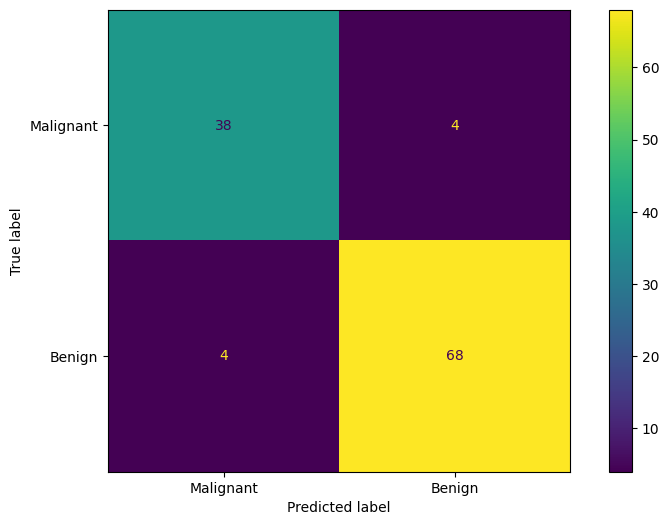

Confusion Matrix:
 [[38  4]
 [ 4 68]]


In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

best_gb_model = gb_cv.best_estimator_

y_test_pred_gb = best_gb_model.predict(X_test)

cm = confusion_matrix(y_test, y_test_pred_gb)

ConfusionMatrixDisplay(cm, display_labels=["Malignant","Benign"]).plot()
plt.show()

print("Confusion Matrix:\n", cm)

The confusion matrix shows the distribution of correct and incorrect predictions.

- True Positives: correctly predicted malignant cases
- True Negatives: correctly predicted benign cases
- False Negatives: malignant cases predicted as benign (most critical error)
- False Positives: benign cases predicted as malignant

In this project, minimizing false negatives is crucial because missing a malignant tumor can have serious consequences.


###Incorrect Predictions

In [ ]:
import numpy as np

wrong_idx = np.where(y_test != y_test_pred_gb)[0]

print("Number of wrong predictions:", len(wrong_idx))

Number of wrong predictions: 8


In [ ]:
for i in wrong_idx[:5]:
    print("Index:", i)
    print("Actual:", y_test.iloc[i])
    print("Predicted:", y_test_pred_gb[i])
    print("-------------------")

Index: 3
Actual: 1
Predicted: 0
-------------------
Index: 35
Actual: 0
Predicted: 1
-------------------
Index: 45
Actual: 1
Predicted: 0
-------------------
Index: 53
Actual: 0
Predicted: 1
-------------------
Index: 65
Actual: 0
Predicted: 1
-------------------


Some incorrect predictions were examined.

The model tends to misclassify certain malignant cases as benign. This may be due to overlapping feature distributions between the classes.

Possible reasons:
- Similar feature values between benign and malignant tumors
- Limited model complexity
- Noise in the data

Improving feature selection or tuning decision thresholds may reduce these errors.

# **Interpretability**

### Feature Importance

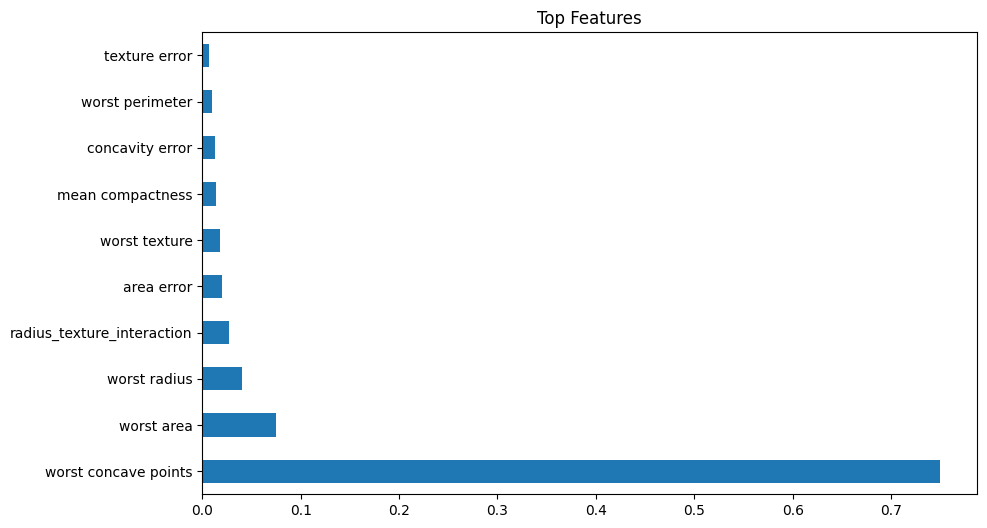

In [ ]:
import pandas as pd

model = best_gb_model

importances = model.feature_importances_

feat_imp = pd.Series(importances, index=X_train.columns)
feat_imp = feat_imp.sort_values(ascending=False)

feat_imp.head(10).plot(kind="barh")
plt.title("Top Features")
plt.show()

Feature importance analysis shows which variables contribute most to the prediction.

The most important features have strong influence on classification decisions.

This helps in understanding the model behavior and increases trust in the predictions.

In medical applications, interpretability is important for explaining decisions to healthcare professionals.






### General Conclusion

Machine learning models are often considered black boxes, but interpretability techniques help us understand their decisions.

In this study, feature importance was used to analyze which variables most influence the prediction of breast cancer diagnosis.

The results indicate that certain features have significantly higher importance scores, meaning they play a critical role in distinguishing malignant and benign tumors.

Understanding these features is especially important in medical applications, where decisions must be explainable and trustworthy.

Additionally, error analysis revealed that some malignant cases are misclassified as benign. This is a critical issue and highlights the importance of optimizing recall for malignant cases.

Further improvements could include threshold tuning and more advanced models.


# **Refined Model & Final Metrics**

## **Interactive Prediction Interface**

To allow for easy interaction with the trained model, we'll create a simple web-based interface using the `gradio` library. This interface will take the 30 original features as input, perform the necessary feature engineering, and then provide a tumor diagnosis (Benign or Malignant) along with the prediction confidence.

In [ ]:
# Install gradio if not already installed
!pip install -q gradio


In [ ]:
import gradio as gr
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# The rf_cv object is already fitted and available from previous cells (e.g., cell 9Z5QopHNYw_D).
# We will directly use its best estimator and the feature names from the global X DataFrame.

best_model = rf_cv.best_estimator_

# Get the feature names from the original X DataFrame
# This ensures the order of inputs to the prediction function matches the model's expectations
feature_names = X.columns.tolist()

def predict_tumor(
    mean_radius, mean_texture, mean_perimeter, mean_area, mean_smoothness,
    mean_compactness, mean_concavity, mean_concave_points, mean_symmetry, mean_fractal_dimension,
    radius_error, texture_error, perimeter_error, area_error, smoothness_error,
    compactness_error, concavity_error, concave_points_error, symmetry_error, fractal_dimension_error,
    worst_radius, worst_texture, worst_perimeter, worst_area, worst_smoothness,
    worst_compactness, worst_concavity, worst_concave_points, worst_symmetry, worst_fractal_dimension
):
    # Create a dictionary from the input features
    input_data = {
        'mean radius': mean_radius,
        'mean texture': mean_texture,
        'mean perimeter': mean_perimeter,
        'mean area': mean_area,
        'mean smoothness': mean_smoothness,
        'mean compactness': mean_compactness,
        'mean concavity': mean_concavity,
        'mean concave points': mean_concave_points,
        'mean symmetry': mean_symmetry,
        'mean fractal dimension': mean_fractal_dimension,
        'radius error': radius_error,
        'texture error': texture_error,
        'perimeter error': perimeter_error,
        'area error': area_error,
        'smoothness error': smoothness_error,
        'compactness error': compactness_error,
        'concavity error': concavity_error,
        'concave points error': concave_points_error,
        'symmetry error': symmetry_error,
        'fractal dimension error': fractal_dimension_error,
        'worst radius': worst_radius,
        'worst texture': worst_texture,
        'worst perimeter': worst_perimeter,
        'worst area': worst_area,
        'worst smoothness': worst_smoothness,
        'worst compactness': worst_compactness,
        'worst concavity': worst_concavity,
        'worst concave points': worst_concave_points,
        'worst symmetry': worst_symmetry,
        'worst fractal dimension': worst_fractal_dimension
    }

    # Convert to pandas DataFrame
    df_sample = pd.DataFrame([input_data], columns=feature_names)

    # Apply feature engineering, matching the notebook's preprocessing
    df_sample["area_perimeter_ratio"] = df_sample["mean area"] / df_sample["mean perimeter"]
    df_sample["radius_texture_interaction"] = df_sample["mean radius"] * df_sample["mean texture"]
    df_sample["compactness_smoothness_ratio"] = df_sample["mean compactness"] / df_sample["mean smoothness"]

    # Make prediction
    prediction = best_model.predict(df_sample)[0]
    probabilities = best_model.predict_proba(df_sample)[0]

    diagnosis = "Benign" if prediction == 1 else "Malignant"
    confidence = np.max(probabilities) * 100

    return diagnosis, f"{confidence:.2f}%"

# Create Gradio Interface inputs
# Use text inputs for all numerical features. Gradio will handle type conversion.
inputs = [
    gr.Slider(minimum=6, maximum=29, value=17.99, label="Mean Radius"),
    gr.Slider(minimum=9, maximum=40, value=10.38, label="Mean Texture"),
    gr.Slider(minimum=43, maximum=189, value=122.80, label="Mean Perimeter"),
    gr.Slider(minimum=140, maximum=2510, value=1001.0, label="Mean Area"),
    gr.Slider(minimum=0.05, maximum=0.17, value=0.11840, label="Mean Smoothness"),
    gr.Slider(minimum=0.01, maximum=0.35, value=0.27760, label="Mean Compactness"),
    gr.Slider(minimum=0.0, maximum=0.43, value=0.3001, label="Mean Concavity"),
    gr.Slider(minimum=0.0, maximum=0.21, value=0.14710, label="Mean Concave Points"),
    gr.Slider(minimum=0.1, maximum=0.31, value=0.2419, label="Mean Symmetry"),
    gr.Slider(minimum=0.04, maximum=0.1, value=0.07871, label="Mean Fractal Dimension"),
    gr.Slider(minimum=0.1, maximum=3, value=1.095, label="Radius Error"),
    gr.Slider(minimum=0.3, maximum=5, value=0.9053, label="Texture Error"),
    gr.Slider(minimum=0.7, maximum=22, value=8.589, label="Perimeter Error"),
    gr.Slider(minimum=6, maximum=545, value=153.4, label="Area Error"),
    gr.Slider(minimum=0.001, maximum=0.01, value=0.006399, label="Smoothness Error"),
    gr.Slider(minimum=0.002, maximum=0.08, value=0.04904, label="Compactness Error"),
    gr.Slider(minimum=0.0, maximum=0.4, value=0.05373, label="Concavity Error"),
    gr.Slider(minimum=0.0, maximum=0.05, value=0.01587, label="Concave Points Error"),
    gr.Slider(minimum=0.008, maximum=0.08, value=0.03003, label="Symmetry Error"),
    gr.Slider(minimum=0.0008, maximum=0.03, value=0.006193, label="Fractal Dimension Error"),
    gr.Slider(minimum=7, maximum=37, value=25.38, label="Worst Radius"),
    gr.Slider(minimum=12, maximum=50, value=17.33, label="Worst Texture"),
    gr.Slider(minimum=50, maximum=252, value=184.60, label="Worst Perimeter"),
    gr.Slider(minimum=180, maximum=4260, value=2019.0, label="Worst Area"),
    gr.Slider(minimum=0.07, maximum=0.23, value=0.1622, label="Worst Smoothness"),
    gr.Slider(minimum=0.02, maximum=1.06, value=0.6656, label="Worst Compactness"),
    gr.Slider(minimum=0.0, maximum=1.26, value=0.7119, label="Worst Concavity"),
    gr.Slider(minimum=0.0, maximum=0.29, value=0.2654, label="Worst Concave Points"),
    gr.Slider(minimum=0.15, maximum=0.67, value=0.4601, label="Worst Symmetry"),
    gr.Slider(minimum=0.05, maximum=0.21, value=0.11890, label="Worst Fractal Dimension")
]

outputs = [
    gr.Textbox(label="Diagnosis"),
    gr.Textbox(label="Confidence")
]

# Create the Gradio interface
iface = gr.Interface(
    fn=predict_tumor,
    inputs=inputs,
    outputs=outputs,
    title="Breast Cancer Diagnosis Predictor",
    description="""Enter the tumor feature values to get a prediction (Benign/Malignant).""",
    flagging_dir="flagged_predictions",
    allow_flagging="manual"
)

# Launch the interface HELLO
iface.launch()

/usr/local/lib/python3.12/dist-packages/gradio/interface.py:415: UserWarning: The `allow_flagging` parameter in `Interface` is deprecated. Use `flagging_mode` instead.
  warnings.warn(


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://3b296358b4ae9ee822.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


### Understanding `flagged_predictions`

The `flagged_predictions` directory is created by Gradio to store data points that users explicitly 'flag' while interacting with the web interface. This is useful for collecting cases where the model might have made a questionable prediction, which can then be reviewed and used to improve the model.

**Key points:**
- The directory will **only be created after you launch the Gradio interface and click the 'Flag' button** on one or more predictions.
- Each flagged entry will typically save the input features and the corresponding model output to a CSV file within this directory.

### Verify `flagged_predictions` directory

After you have launched the Gradio interface (by running the code cell above) and flagged at least one prediction, you can run the following command to check if the `flagged_predictions` directory has been created in your current working directory.

In [ ]:
!ls -F

flagged_predictions/  sample_data/


If the `flagged_predictions/` directory appears in the output of the above command, it means Gradio successfully created it. You can then navigate into that directory to see the saved flagged data.

### Final Model Selection

In [ ]:
final_models_tuned = {
    "SVM": (svm_cv.best_estimator_, True),
    "Random Forest": (rf_cv.best_estimator_, False),
    "Gradient Boosting": (gb_cv.best_estimator_, False)
}

final_results = []

for name, (model, needs_scaling) in final_models_tuned.items():
    # Select the appropriate validation set based on whether the model needs scaling
    Xv_for_prediction = X_val_pipeline if needs_scaling else X_val

    y_pred = model.predict(Xv_for_prediction)
    y_prob = model.predict_proba(Xv_for_prediction)[:,1]

    final_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_val, y_pred),
        "Precision": precision_score(y_val, y_pred),
        "Recall": recall_score(y_val, y_pred),
        "F1-Score": f1_score(y_val, y_pred),
        "ROC-AUC": roc_auc_score(y_val, y_prob)
    })

final_results_df = pd.DataFrame(final_results)
final_results_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,SVM,0.728070,0.696078,1.000000,0.820809,0.989846
1,Random Forest,0.956140,0.958333,0.971831,0.965035,0.987226
2,Gradient Boosting,0.964912,0.958904,0.985915,0.972222,0.966590


Among the advanced models, Random Forest and SVM achieved strong classification performance.

Random Forest was selected as the final model because it provided a strong balance between recall, ROC-AUC, and overall classification performance.

Recall was considered the most important metric because missing malignant cancer cases can have serious medical consequences.

### Threshold Analysis

In [ ]:
best_model = rf_cv.best_estimator_

y_probs = best_model.predict_proba(X_val)[:,1]

thresholds = [0.3, 0.5, 0.7]

for threshold in thresholds:

    y_pred_threshold = (y_probs >= threshold).astype(int)

    print(f"\nThreshold: {threshold}")
    print(classification_report(y_val, y_pred_threshold))


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.95      0.86      0.90        43
           1       0.92      0.97      0.95        71

    accuracy                           0.93       114
   macro avg       0.93      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.95      0.93      0.94        43
           1       0.96      0.97      0.97        71

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114


Threshold: 0.7
              precision    recall  f1-score   support

           0       0.91      0.98      0.94        43
           1       0.99      0.94      0.96        71

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96   

Lower thresholds increase recall and reduce the probability of missing malignant tumors.

However, lower thresholds may also increase false positive predictions.

For medical diagnosis tasks, recall is especially important because false negatives can lead to dangerous outcomes.

### Final Confusion Matrix

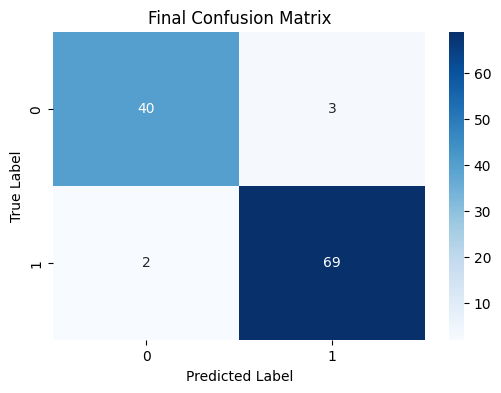

In [ ]:
best_model = rf_cv.best_estimator_

y_pred = best_model.predict(X_val)

cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Final Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

The confusion matrix shows that the model correctly classified most benign and malignant tumors.

False negatives were minimized, which is especially important in medical diagnosis applications because missing malignant cases may lead to serious consequences.

###Feature Importance Analysis

In [ ]:
best_rf = rf_cv.best_estimator_

importances = best_rf.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importances
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_df.head(10)

,Feature,Importance
27,worst concave points,0.155523
22,worst perimeter,0.120944
23,worst area,0.104283
20,worst radius,0.083072
7,mean concave points,0.073478
31,radius_texture_interaction,0.056538
2,mean perimeter,0.054661
6,mean concavity,0.051786
13,area error,0.034755
3,mean area,0.031406


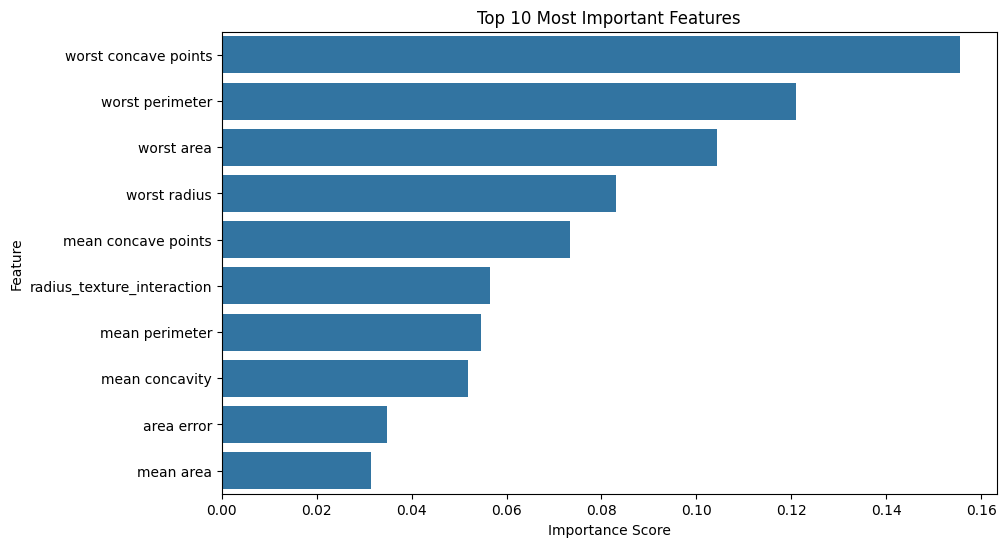

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance_df.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Most Important Features")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.show()

The Random Forest model identified several highly influential clinical features for tumor classification.

These features contributed significantly to distinguishing malignant tumors from benign tumors.

Feature importance analysis also improves model interpretability and helps explain the model’s decision-making process.

### Simple Prediction Demo

In [ ]:
sample_patient = X_val.iloc[[0]]

prediction = best_rf.predict(sample_patient)
probability = best_rf.predict_proba(sample_patient)

print("Prediction Result")
print("------------------")

if prediction[0] == 1:
    print("Tumor Type: Benign")
else:
    print("Tumor Type: Malignant")

print(f"Prediction Confidence: {np.max(probability)*100:.2f}%")

Prediction Result
------------------
Tumor Type: Benign
Prediction Confidence: 96.57%


This demo simulates how the trained machine learning model can classify tumors using patient clinical feature values.

The system predicts whether a tumor is malignant or benign based on the learned patterns from the training data.